# Prediksi Harga Pangan - XGBoost Regressor
**Target:** Prediksi harga daging ayam 30 hari ke depan (recursive forecasting)

**Alur:**
1. Setup & Load Data
2. Preprocessing
3. Feature Engineering
4. Train/Test Split (time-aware)
5. Training XGBoost
6. Evaluasi (MAE, RMSE, MAPE)
7. Recursive Forecasting 30 Hari
8. Visualisasi

## 1. SETUP

In [17]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Reproducibility
np.random.seed(42)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. LOAD DATA

In [19]:
# Sesuaikan path-nya
DATA_PATH = "C:/Users/visco/RoadtoML/harga pangan/Tabel Harga Ayam Berdasarkan Daerah.csv"

data = pd.read_csv(DATA_PATH, na_values='-')

print(f'Shape: {data.shape}')
print(f'Kolom: {data.columns[:5].tolist()} ... {data.columns[-3:].tolist()}')
data.head()

Shape: (1, 1152)
Kolom: ['No', 'Komoditas (Rp)', '03/ 01/ 2022', '04/ 01/ 2022', '05/ 01/ 2022'] ... ['27/ 05/ 2026', '28/ 05/ 2026', '29/ 05/ 2026']


,No,Komoditas (Rp),03/ 01/ 2022,04/ 01/ 2022,05/ 01/ 2022,06/ 01/ 2022,07/ 01/ 2022,10/ 01/ 2022,11/ 01/ 2022,12/ 01/ 2022,...,18/ 05/ 2026,19/ 05/ 2026,20/ 05/ 2026,21/ 05/ 2026,22/ 05/ 2026,25/ 05/ 2026,26/ 05/ 2026,27/ 05/ 2026,28/ 05/ 2026,29/ 05/ 2026
0,I,Daging Ayam,"35,350","35,300","35,050","34,800","34,950","36,400","37,000","37,250",...,"35,850","35,750","35,500","35,600","35,850","35,850","35,750",NaN,NaN,"35,750"


## 3. PREPROCESSING

In [20]:
# --- 3a. Hapus kolom 'No', pakai 'Komoditas' sebagai id ---
id_col = data.columns[1]   # 'Komoditas (Rp)'
date_cols = data.columns[2:]

# --- 3b. Bersihkan format angka (hapus koma ribuan) ---
data[date_cols] = data[date_cols].replace(',', '', regex=True)
data[date_cols] = data[date_cols].apply(pd.to_numeric, errors='coerce')

# --- 3c. Wide → Long ---
df = data.melt(
    id_vars=[id_col],
    var_name='Tanggal',
    value_name='Harga'
).rename(columns={id_col: 'Komoditas'})

# --- 3d. Parse tanggal ---
df['Tanggal'] = pd.to_datetime(df['Tanggal'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Tanggal'])
df = df.sort_values(['Komoditas', 'Tanggal']).reset_index(drop=True)

print(f'Jumlah baris setelah wide→long: {len(df)}')
print(f'Periode: {df.Tanggal.min().date()} s/d {df.Tanggal.max().date()}')
print(f'Komoditas unik: {df.Komoditas.unique()}')
df.head()

Jumlah baris setelah wide→long: 1150
Periode: 2022-01-03 s/d 2026-05-29
Komoditas unik: ['Daging Ayam']


,Komoditas,Tanggal,Harga
0,Daging Ayam,2022-01-03,35350
1,Daging Ayam,2022-01-04,35300
2,Daging Ayam,2022-01-05,35050
3,Daging Ayam,2022-01-06,34800
4,Daging Ayam,2022-01-07,34950


In [21]:
# --- 3e. Handle missing value per komoditas ---
# Pakai forward fill dulu (harga terakhir diketahui),
# lalu rolling mean 7 hari untuk gap yang lebih panjang

def fill_missing(group):
    group = group.copy()
    # Forward fill untuk gap pendek (weekend, libur)
    group['Harga'] = group['Harga'].ffill()
    # Backward fill untuk missing di awal
    group['Harga'] = group['Harga'].bfill()
    return group

df = df.groupby('Komoditas', group_keys=False).apply(fill_missing)

missing_after = df['Harga'].isna().sum()
print(f'Missing value setelah imputasi: {missing_after}')

Missing value setelah imputasi: 0


## 4. FEATURE ENGINEERING

Fitur yang dibuat:
- **Lag features**: harga 1, 2, 3, 5, 7, 14, 21, 30 hari sebelumnya
- **Rolling statistics**: rolling mean & std 7 dan 30 hari
- **Calendar features**: hari dalam minggu, bulan, kuartal, apakah hari kerja
- **Trend feature**: selisih harga dari 7 hari lalu

In [22]:
def build_features(group):
    g = group.copy().sort_values('Tanggal')
    h = g['Harga']

    # --- Lag features ---
    for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
        g[f'lag_{lag}'] = h.shift(lag)

    # --- Rolling statistics ---
    g['roll_mean_7']  = h.shift(1).rolling(7,  min_periods=1).mean()
    g['roll_mean_30'] = h.shift(1).rolling(30, min_periods=1).mean()
    g['roll_std_7']   = h.shift(1).rolling(7,  min_periods=1).std().fillna(0)
    g['roll_std_30']  = h.shift(1).rolling(30, min_periods=1).std().fillna(0)

    # --- Trend ---
    g['trend_7']  = h.shift(1) - h.shift(7)
    g['trend_30'] = h.shift(1) - h.shift(30)

    # --- Calendar features ---
    g['day_of_week'] = g['Tanggal'].dt.dayofweek      # 0=Senin
    g['month']       = g['Tanggal'].dt.month
    g['quarter']     = g['Tanggal'].dt.quarter
    g['day_of_year'] = g['Tanggal'].dt.dayofyear
    g['week_of_year']= g['Tanggal'].dt.isocalendar().week.astype(int)
    g['is_month_end']= g['Tanggal'].dt.is_month_end.astype(int)

    return g

df_feat = df.groupby('Komoditas', group_keys=False).apply(build_features)
df_feat = df_feat.dropna()   # hapus baris yang lag-nya belum tersedia
df_feat = df_feat.reset_index(drop=True)

print(f'Shape setelah feature engineering: {df_feat.shape}')
print(f'Fitur: {[c for c in df_feat.columns if c not in ["Komoditas","Tanggal","Harga"]]}')
df_feat.head(3)

Shape setelah feature engineering: (1120, 23)
Fitur: ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'lag_30', 'roll_mean_7', 'roll_mean_30', 'roll_std_7', 'roll_std_30', 'trend_7', 'trend_30', 'day_of_week', 'month', 'quarter', 'day_of_year', 'week_of_year', 'is_month_end']


,Komoditas,Tanggal,Harga,lag_1,lag_2,lag_3,lag_5,lag_7,lag_14,lag_21,...,roll_std_7,roll_std_30,trend_7,trend_30,day_of_week,month,quarter,day_of_year,week_of_year,is_month_end
0,Daging Ayam,2022-02-14,32250,32500.0,32550.0,32600.0,32850.0,34150.0,36500.0,37500.0,...,668.331255,1699.69994,-1650.0,-2850.0,0,2,1,45,7,0
1,Daging Ayam,2022-02-15,32150,32250.0,32500.0,32550.0,32600.0,33750.0,36150.0,37500.0,...,483.784683,1796.91706,-1500.0,-3050.0,1,2,1,46,7,0
2,Daging Ayam,2022-02-16,32000,32150.0,32250.0,32500.0,32600.0,32850.0,35900.0,37400.0,...,234.520788,1888.91199,-700.0,-2900.0,2,2,1,47,7,0


## 5. TRAIN / TEST SPLIT

Pakai **time-based split** — bukan random split.
Data 30 hari terakhir dijadikan test set (simulasi prediksi masa depan).

In [23]:
FORECAST_HORIZON = 30   # hari yang mau diprediksi

FEATURE_COLS = [
    'lag_1','lag_2','lag_3','lag_5','lag_7','lag_14','lag_21','lag_30',
    'roll_mean_7','roll_mean_30','roll_std_7','roll_std_30',
    'trend_7','trend_30',
    'day_of_week','month','quarter','day_of_year','week_of_year','is_month_end'
]
TARGET_COL = 'Harga'

# Split per komoditas supaya tidak bocor antar komoditas
cutoff_date = df_feat['Tanggal'].max() - pd.Timedelta(days=FORECAST_HORIZON)

train = df_feat[df_feat['Tanggal'] <= cutoff_date]
test  = df_feat[df_feat['Tanggal'] >  cutoff_date]

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET_COL]

print(f'Train: {len(X_train)} baris | {train.Tanggal.min().date()} → {train.Tanggal.max().date()}')
print(f'Test : {len(X_test)}  baris | {test.Tanggal.min().date()} → {test.Tanggal.max().date()}')

Train: 1098 baris | 2022-02-14 → 2026-04-29
Test : 22  baris | 2026-04-30 → 2026-05-29


## 6. TRAINING XGBOOST

In [24]:
model = XGBRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 5,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,
    reg_alpha         = 0.1,    # L1
    reg_lambda        = 1.0,    # L2
    random_state      = 42,
    n_jobs            = -1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print('\nModel trained!')

[0]	validation_0-rmse:980.65192
[100]	validation_0-rmse:249.28444


[200]	validation_0-rmse:239.45443
[300]	validation_0-rmse:240.04282
[400]	validation_0-rmse:237.81095
[499]	validation_0-rmse:236.00690

Model trained!


## 7. EVALUASI

In [25]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

print('='*40)
print('       HASIL EVALUASI MODEL')
print('='*40)
print(f'  MAE  : Rp {mae:,.0f}')
print(f'  RMSE : Rp {rmse:,.0f}')
print(f'  MAPE : {mape:.2f}%')
print('='*40)
print(f'\n  Interpretasi MAPE:')
print(f'  < 10% → Sangat Baik')
print(f'  10-20% → Baik')
print(f'  > 20% → Perlu perbaikan')

       HASIL EVALUASI MODEL
  MAE  : Rp 202
  RMSE : Rp 236
  MAPE : 0.56%

  Interpretasi MAPE:
  < 10% → Sangat Baik
  10-20% → Baik
  > 20% → Perlu perbaikan


## 8. RECURSIVE FORECASTING 30 HARI KE DEPAN

Prediksi iteratif: hasil prediksi hari ini dijadikan input lag untuk hari berikutnya.

In [26]:
def recursive_forecast(model, history_df, n_days=365, feature_cols=FEATURE_COLS):
    """
    Prediksi n_days ke depan secara rekursif.
    history_df: DataFrame dengan kolom Tanggal & Harga (semua data historis)
    """
    history = history_df[['Tanggal', 'Harga']].copy().sort_values('Tanggal')
    predictions = []
    future_dates = pd.bdate_range(
        start=history['Tanggal'].max() + pd.Timedelta(days=1),
        periods=n_days
    )

    for future_date in future_dates:
        h = history['Harga']

        # Build fitur untuk hari ini
        row = {
            'lag_1' : h.iloc[-1],
            'lag_2' : h.iloc[-2]  if len(h) >= 2  else h.iloc[-1],
            'lag_3' : h.iloc[-3]  if len(h) >= 3  else h.iloc[-1],
            'lag_5' : h.iloc[-5]  if len(h) >= 5  else h.iloc[-1],
            'lag_7' : h.iloc[-7]  if len(h) >= 7  else h.iloc[-1],
            'lag_14': h.iloc[-14] if len(h) >= 14 else h.iloc[-1],
            'lag_21': h.iloc[-21] if len(h) >= 21 else h.iloc[-1],
            'lag_30': h.iloc[-30] if len(h) >= 30 else h.iloc[-1],

            'roll_mean_7' : h.iloc[-7:].mean(),
            'roll_mean_30': h.iloc[-30:].mean(),
            'roll_std_7'  : h.iloc[-7:].std() if len(h) >= 2 else 0,
            'roll_std_30' : h.iloc[-30:].std() if len(h) >= 2 else 0,

            'trend_7' : h.iloc[-1] - (h.iloc[-7]  if len(h) >= 7  else h.iloc[0]),
            'trend_30': h.iloc[-1] - (h.iloc[-30] if len(h) >= 30 else h.iloc[0]),

            'day_of_week' : future_date.dayofweek,
            'month'       : future_date.month,
            'quarter'     : future_date.quarter,
            'day_of_year' : future_date.dayofyear,
            'week_of_year': future_date.isocalendar()[1],
            'is_month_end': int(future_date == future_date + pd.offsets.MonthEnd(0)),
        }

        X_pred = pd.DataFrame([row])[feature_cols]
        pred   = model.predict(X_pred)[0]

        predictions.append({'Tanggal': future_date, 'Harga_Prediksi': pred})

        # Update history dengan hasil prediksi
        new_row = pd.DataFrame([{'Tanggal': future_date, 'Harga': pred}])
        history = pd.concat([history, new_row], ignore_index=True)

    return pd.DataFrame(predictions)


# Ambil satu komoditas untuk forecast
komoditas_target = df_feat['Komoditas'].unique()[0]
history_komoditas = df_feat[df_feat['Komoditas'] == komoditas_target][['Tanggal', 'Harga']]

forecast_df = recursive_forecast(model, history_komoditas, n_days=365)

print(f'Prediksi 30 hari ke depan untuk: {komoditas_target}')
print(forecast_df.to_string(index=False))

Prediksi 30 hari ke depan untuk: Daging Ayam
   Tanggal  Harga_Prediksi
2026-06-01    35652.125000
2026-06-02    35454.062500
2026-06-03    35306.785156
2026-06-04    35264.644531
2026-06-05    35229.839844
2026-06-08    35124.214844
2026-06-09    35143.296875
2026-06-10    35098.218750
2026-06-11    35039.503906
2026-06-12    35017.566406
2026-06-15    35010.164062
2026-06-16    35067.593750
2026-06-17    34980.628906
2026-06-18    34981.808594
2026-06-19    34942.007812
2026-06-22    34841.175781
2026-06-23    34686.960938
2026-06-24    34639.398438
2026-06-25    34493.957031
2026-06-26    34372.164062
2026-06-29    34148.246094
2026-06-30    33827.281250
2026-07-01    33661.292969
2026-07-02    33718.507812
2026-07-03    33751.097656
2026-07-06    33756.011719
2026-07-07    33795.144531
2026-07-08    33759.332031
2026-07-09    33759.417969
2026-07-10    33777.796875
2026-07-13    33564.667969
2026-07-14    33638.023438
2026-07-15    33702.664062
2026-07-16    33839.953125
2026-07-17

## 9. VISUALISASI

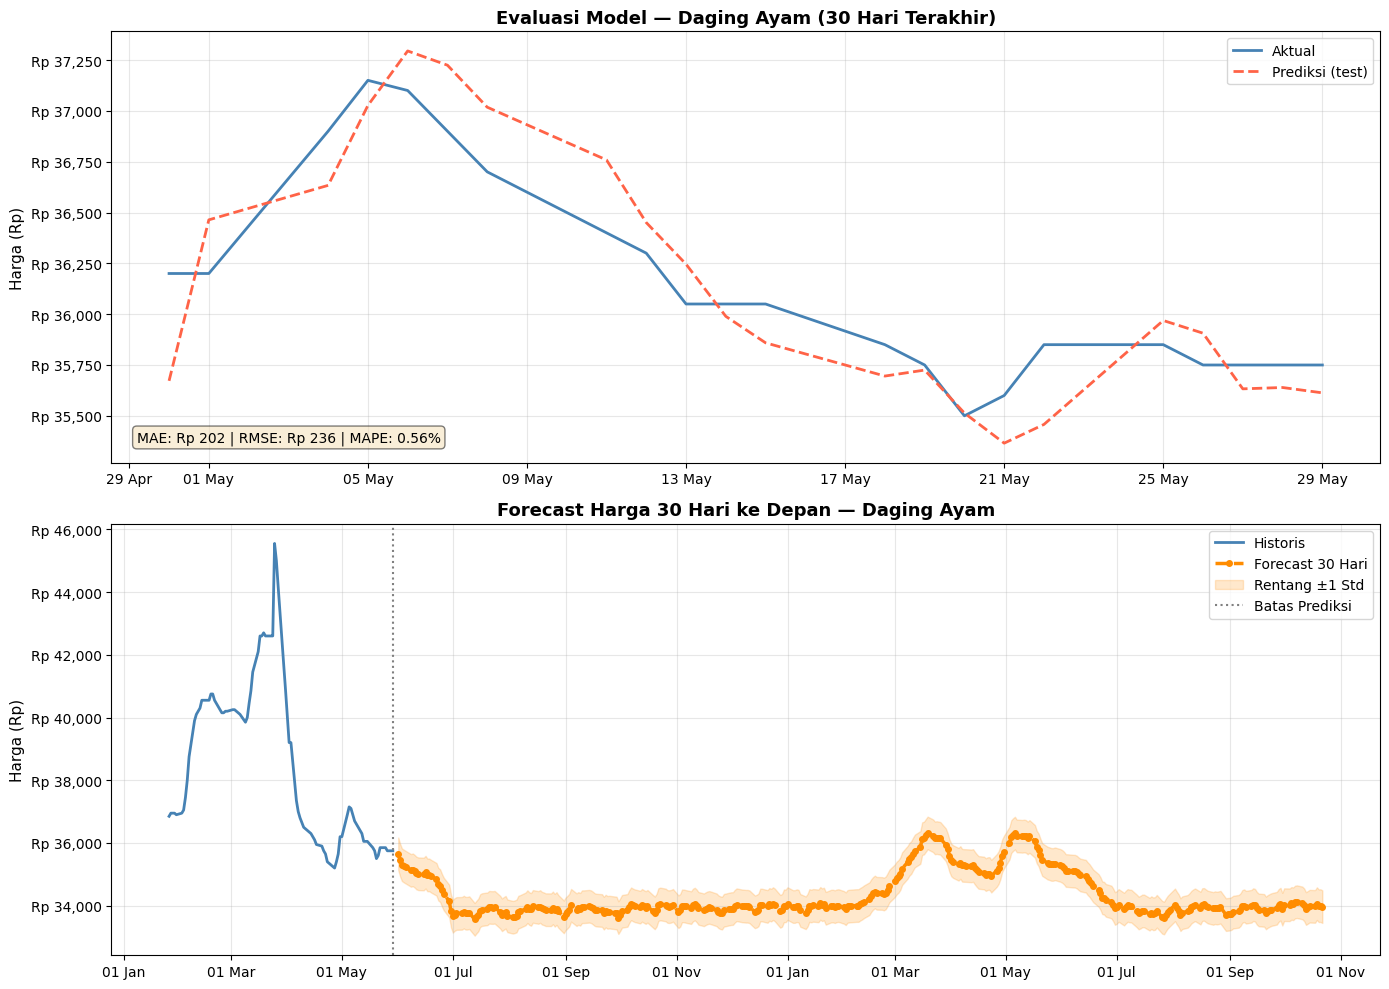

Plot disimpan: forecast_result.png


In [27]:
# --- Plot 1: Actual vs Predicted (test set) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Test set evaluation
ax1 = axes[0]
test_plot = test[test['Komoditas'] == komoditas_target].copy()
ax1.plot(test_plot['Tanggal'], test_plot['Harga'], label='Aktual', color='steelblue', linewidth=2)
ax1.plot(test_plot['Tanggal'], model.predict(test_plot[FEATURE_COLS]),
         label='Prediksi (test)', color='tomato', linewidth=2, linestyle='--')
ax1.set_title(f'Evaluasi Model — {komoditas_target} (30 Hari Terakhir)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Harga (Rp)', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.annotate(f'MAE: Rp {mae:,.0f} | RMSE: Rp {rmse:,.0f} | MAPE: {mape:.2f}%',
             xy=(0.02, 0.05), xycoords='axes fraction', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Subplot 2: Recursive forecast 30 hari ke depan
ax2 = axes[1]
# Tampilkan 90 hari historis + 30 hari prediksi
hist_plot = history_komoditas.tail(90)
ax2.plot(hist_plot['Tanggal'], hist_plot['Harga'],
         label='Historis', color='steelblue', linewidth=2)
ax2.plot(forecast_df['Tanggal'], forecast_df['Harga_Prediksi'],
         label='Forecast 30 Hari', color='darkorange', linewidth=2.5,
         linestyle='--', marker='o', markersize=4)
# Confidence interval sederhana (±1 std rolling)
std_hist = history_komoditas['Harga'].tail(30).std()
ax2.fill_between(forecast_df['Tanggal'],
                 forecast_df['Harga_Prediksi'] - std_hist,
                 forecast_df['Harga_Prediksi'] + std_hist,
                 alpha=0.2, color='darkorange', label='Rentang ±1 Std')
ax2.axvline(x=history_komoditas['Tanggal'].max(), color='gray',
            linestyle=':', linewidth=1.5, label='Batas Prediksi')
ax2.set_title(f'Forecast Harga 30 Hari ke Depan — {komoditas_target}', fontsize=13, fontweight='bold')
ax2.set_ylabel('Harga (Rp)', fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.savefig('forecast_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan: forecast_result.png')

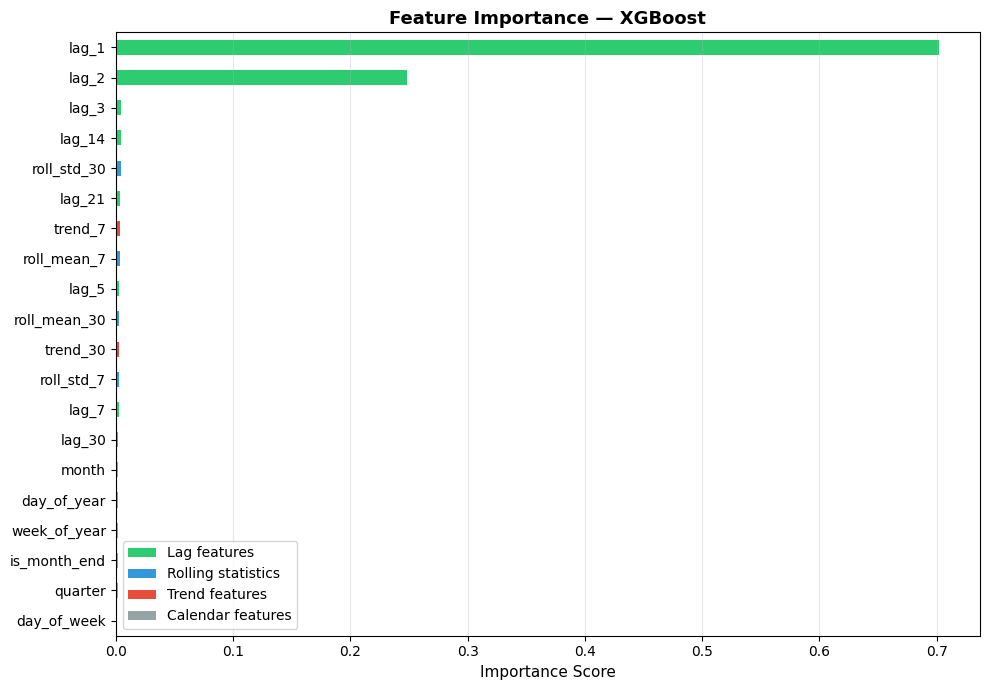

Plot disimpan: feature_importance.png


In [28]:
# --- Plot 2: Feature Importance ---
feat_imp = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71' if 'lag' in f else '#3498db' if 'roll' in f
          else '#e74c3c' if 'trend' in f else '#95a5a6'
          for f in feat_imp.index]
feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance — XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)

# Legend manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Lag features'),
    Patch(facecolor='#3498db', label='Rolling statistics'),
    Patch(facecolor='#e74c3c', label='Trend features'),
    Patch(facecolor='#95a5a6', label='Calendar features'),
]
ax.legend(handles=legend_elements, fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan: feature_importance.png')

In [29]:
# --- Simpan hasil forecast ke CSV ---
forecast_df['Komoditas'] = komoditas_target
forecast_df['Harga_Prediksi'] = forecast_df['Harga_Prediksi'].round(0).astype(int)
forecast_df.to_csv('hasil_forecast_30hari.csv', index=False)

print('=== RINGKASAN PREDIKSI 30 HARI ===')
print(f'Harga terakhir (aktual) : Rp {history_komoditas["Harga"].iloc[-1]:,.0f}')
print(f'Rata-rata prediksi      : Rp {forecast_df["Harga_Prediksi"].mean():,.0f}')
print(f'Harga min prediksi      : Rp {forecast_df["Harga_Prediksi"].min():,.0f}')
print(f'Harga maks prediksi     : Rp {forecast_df["Harga_Prediksi"].max():,.0f}')
print()
print(forecast_df[['Tanggal','Harga_Prediksi']].to_string(index=False))

=== RINGKASAN PREDIKSI 30 HARI ===
Harga terakhir (aktual) : Rp 35,750
Rata-rata prediksi      : Rp 34,334
Harga min prediksi      : Rp 33,565
Harga maks prediksi     : Rp 36,319

   Tanggal  Harga_Prediksi
2026-06-01           35652
2026-06-02           35454
2026-06-03           35307
2026-06-04           35265
2026-06-05           35230
2026-06-08           35124
2026-06-09           35143
2026-06-10           35098
2026-06-11           35040
2026-06-12           35018
2026-06-15           35010
2026-06-16           35068
2026-06-17           34981
2026-06-18           34982
2026-06-19           34942
2026-06-22           34841
2026-06-23           34687
2026-06-24           34639
2026-06-25           34494
2026-06-26           34372
2026-06-29           34148
2026-06-30           33827
2026-07-01           33661
2026-07-02           33719
2026-07-03           33751
2026-07-06           33756
2026-07-07           33795
2026-07-08           33759
2026-07-09           33759
2026-07-10